# Chapter 3: Power and sample size

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from expkit.power.binomial import normal_approx_power, required_n, mde, simulate_rejection_rate
from expkit.plot.style import apply_style, PALETTE
apply_style()

## Loop A: power vs N for several effects

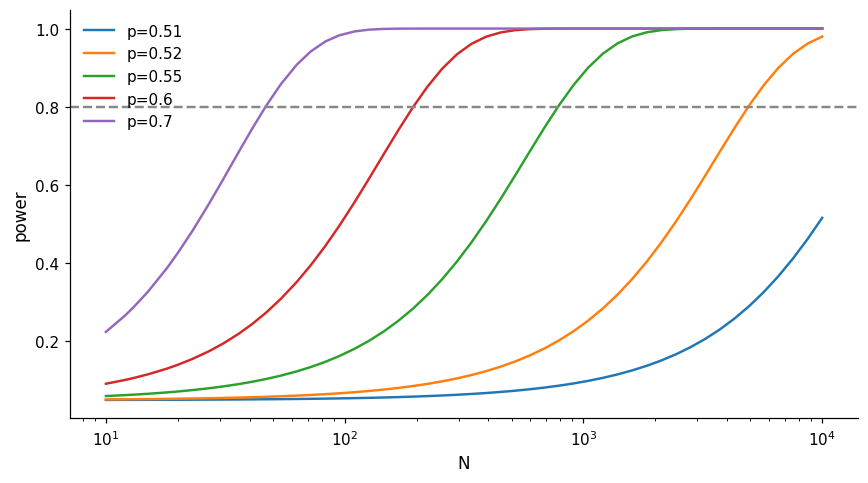

In [2]:
ns = np.unique(np.round(np.geomspace(10, 10000, 50)).astype(int))
fig, ax = plt.subplots()
for p in [0.51, 0.52, 0.55, 0.60, 0.70]:
    powers = [normal_approx_power(0.5, p, n=int(n)) for n in ns]
    ax.plot(ns, powers, label=f'p={p}')
ax.axhline(0.8, color=PALETTE['muted'], linestyle='--')
ax.set_xscale('log'); ax.set_xlabel('N'); ax.set_ylabel('power'); ax.legend()
fig.tight_layout(); plt.show()

## Loop B: required N for various effects

In [3]:
for p in [0.51, 0.52, 0.55, 0.60, 0.70]:
    print(f'effect to {p}: required N at 80% power = {required_n(0.5, p, power=0.8):>7,}')

effect to 0.51: required N at 80% power =  19,620
effect to 0.52: required N at 80% power =   4,904
effect to 0.55: required N at 80% power =     783
effect to 0.6: required N at 80% power =     194
effect to 0.7: required N at 80% power =      47


## Loop C: MDE for a given N

In [4]:
for n in [100, 1000, 10000, 100000]:
    e = mde(0.5, n=n, power=0.8)
    print(f'N = {n:>7,}  MDE at 80% power = {e:.4f} ({e*100:.2f}pp)')

N =     100  MDE at 80% power = 0.1231 (12.31pp)


N =   1,000  MDE at 80% power = 0.0395 (3.95pp)


N =  10,000  MDE at 80% power = 0.0126 (1.26pp)


N = 100,000  MDE at 80% power = 0.0041 (0.41pp)


## Loop D: empirical match to power formulas

In [5]:
for n in [100, 500, 1000, 5000]:
    formula = normal_approx_power(0.5, 0.55, n=n)
    empirical = simulate_rejection_rate(0.55, n=n, p_null=0.5, alpha=0.05, n_experiments=2000, seed=0)
    print(f'N={n:>5}  formula power = {formula:.3f}  empirical rejection rate = {empirical:.3f}')

N=  100  formula power = 0.169  empirical rejection rate = 0.145


N=  500  formula power = 0.609  empirical rejection rate = 0.593


N= 1000  formula power = 0.887  empirical rejection rate = 0.874


N= 5000  formula power = 1.000  empirical rejection rate = 1.000
